In [1]:
import numpy as np
import matplotlib.pyplot as plt

from epot import compute_T_X_to_Z_C, sample_from_gmm

In [2]:
# ---------------------------------------
# 1. GMM A（左下：2成分）
# ---------------------------------------
alpha_A = np.array([0.5, 0.5])

means_A = np.array(
    [
        [-8.0, -5.0],  # A1（左下）
        [1.0, -8.0],  # A2（左下・やや右）
    ]
)

covs_A = 0.2 * np.array(
    [
        [[1, 0.2], [0.2, 1]],
        [[1, -0.1], [-0.1, 1]],
    ]
)

gmm_A = [2, alpha_A, means_A, covs_A]

# ---------------------------------------
# 2. GMM B（右上：2成分 + ノイズ1成分）
# ---------------------------------------
alpha_B = np.array([0.45, 0.45, 0.1])

means_B = np.array(
    [
        [-3.5, 3.5],  # B1（右上）
        [3.5, 3.5],  # B2（右上・やや右）
        [9.0, 7.5],  # B3（ノイズ：さらに右）
    ]
)

covs_B = 0.2 * np.array(
    [
        [[1, -0.1], [-0.1, 1]],
        [[1, 0.2], [0.2, 1]],
        [[1, 0.0], [0.0, 1]],  # ノイズは等方
    ]
)

gmm_B = [3, alpha_B, means_B, covs_B]

/tmp/ipykernel_57710/1732687968.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


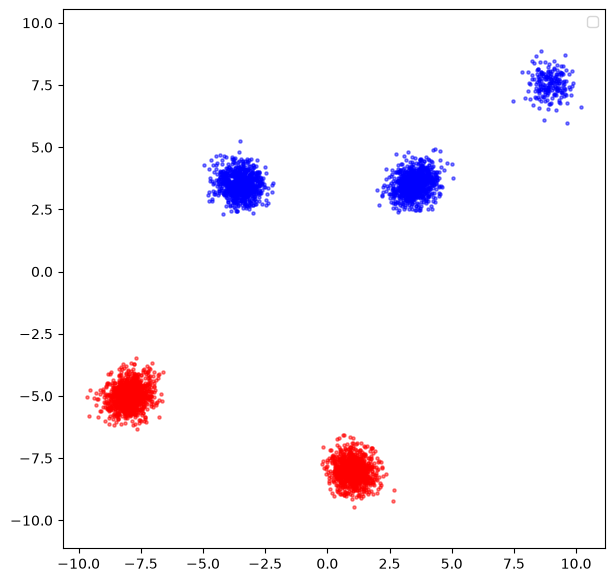

In [3]:
# ---------------------------------------
# gmm_A からサンプル
# ---------------------------------------
_, alpha_A, means_A, covs_A = gmm_A
X = sample_from_gmm(alpha_A, means_A, covs_A, N=2000)

# ---------------------------------------
# gmm_B からサンプル
# ---------------------------------------
_, alpha_B, means_B, covs_B = gmm_B
Y = sample_from_gmm(alpha_B, means_B, covs_B, N=2000)

plt.figure(figsize=(7, 7))
plt.scatter(X[:, 0], X[:, 1], s=5, c="red", alpha=0.5)
plt.scatter(Y[:, 0], Y[:, 1], s=5, c="blue", alpha=0.5)
plt.legend()
plt.axis("equal")

plt.show()

[[4.65892897e-03 1.18710064e-01 4.65751118e-07]
 [4.53341071e-01 9.02811333e-04 1.38879439e-11]]
0.5776133407658054


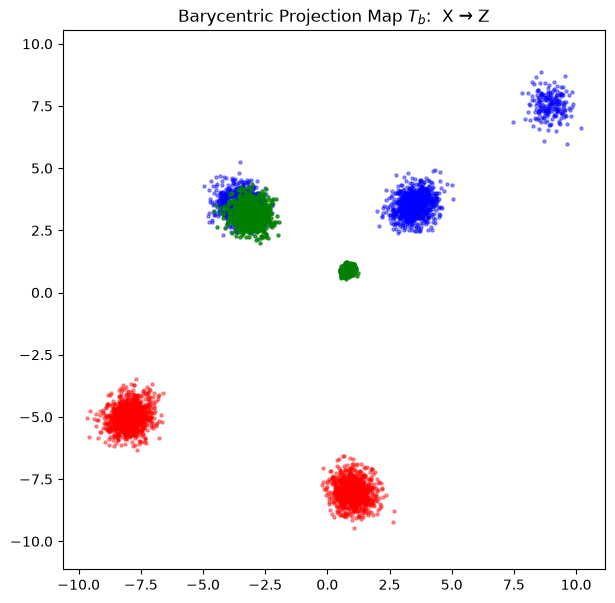

[[-2.68209862  2.59978125]
 [ 0.68113307  0.74913129]
 [ 0.77789616  0.90715448]
 ...
 [ 0.74529327  0.90989417]
 [ 0.68272917  0.80977101]
 [ 0.74797221  0.86303631]]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


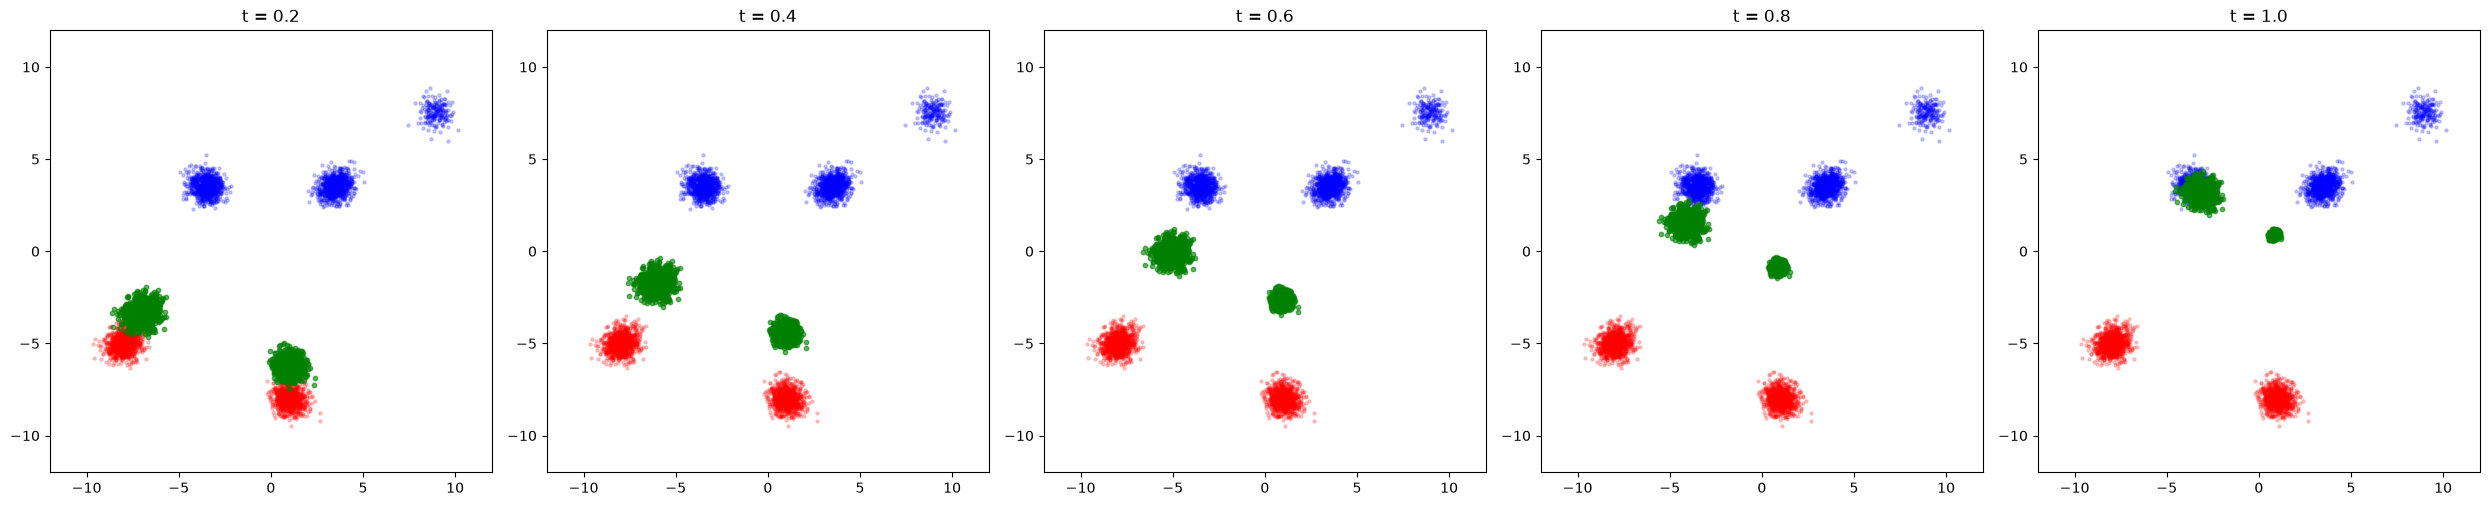

In [4]:
Lambda = 0.25
epsilon = 0.03
# --- Z を計算 ---
Z = compute_T_X_to_Z_C(
    X,
    Y,
    n_components_X=2,
    n_components_Y=3,  # 元の GMM 推定に合わせて適宜変える
    epsilon=epsilon,
    Lambda=Lambda,
    nb_dummies=1,
)


# --- 可視化 ---
plt.figure(figsize=(7, 7))

xmin, xmax = [-12, 12]
ymin, ymax = [-12, 12]

# 元の X（青）
plt.scatter(X[:, 0], X[:, 1], s=5, c="red", alpha=0.4)

# 元の Y（赤）
plt.scatter(Y[:, 0], Y[:, 1], s=5, c="blue", alpha=0.4)

# 移送後 Z（緑）
plt.scatter(Z[:, 0], Z[:, 1], s=5, c="green", alpha=0.7)

plt.axis("equal")
plt.title("Barycentric Projection Map $T_b$:  X → Z")
ax_main = plt.gca()

plt.show()
print(Z)


# パラメータ設定
ts = np.arange(0.2, 1.01, 0.2)
n_plots = len(ts)

# 横一列に並べるための設定
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

for i, t in enumerate(ts):
    # 線形補間
    Pt = (1 - t) * X + t * Z

    ax = axes[i]

    # 背景として X と Y を描画
    ax.scatter(X[:, 0], X[:, 1], s=5, c="red", alpha=0.2, label="X")
    ax.scatter(Y[:, 0], Y[:, 1], s=5, c="blue", alpha=0.2, label="Y")

    # 現在の補間点 Pt を描画
    ax.scatter(Pt[:, 0], Pt[:, 1], s=10, c="green", alpha=0.6, label="P_t")

    ax.set_title(f"t = {t:.1f}")
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)


plt.tight_layout()

plt.savefig(
    f"point_reg_{epsilon}_lambda_{Lambda}.eps", format="eps", bbox_inches="tight"
)
plt.show()

[[4.65892897e-03 4.39160109e-01 1.93764668e-03]
 [4.53341071e-01 3.33989142e-03 5.77774852e-08]]
0.9024377044569724


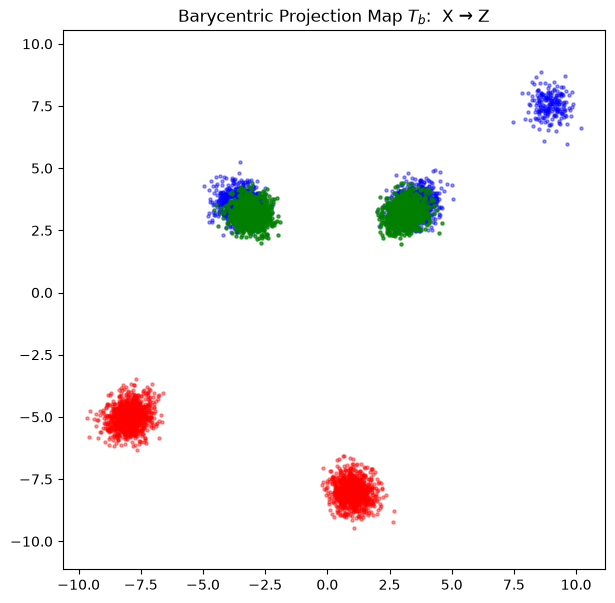

[[-2.66339757  2.61407643]
 [ 2.65398159  2.72096186]
 [ 3.0058254   3.29321807]
 ...
 [ 2.88804709  3.30271033]
 [ 2.66058369  2.94011428]
 [ 2.89708321  3.13341461]]


In [5]:
Lambda = 0.5
epsilon = 0.03
# --- Z を計算 ---
Z = compute_T_X_to_Z_C(
    X,
    Y,
    n_components_X=2,
    n_components_Y=3,  # 元の GMM 推定に合わせて適宜変える
    epsilon=epsilon,
    Lambda=Lambda,
    nb_dummies=1,
)


# --- 可視化 ---
plt.figure(figsize=(7, 7))

# 元の X（青）
plt.scatter(X[:, 0], X[:, 1], s=5, c="red", alpha=0.4)

# 元の Y（赤）
plt.scatter(Y[:, 0], Y[:, 1], s=5, c="blue", alpha=0.4)

# 移送後 Z（緑）
plt.scatter(Z[:, 0], Z[:, 1], s=5, c="green", alpha=0.7)

plt.axis("equal")
plt.title("Barycentric Projection Map $T_b$:  X → Z")
ax_main = plt.gca()
xmin, xmax = [-12, 12]
ymin, ymax = [-12, 12]
plt.show()
print(Z)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


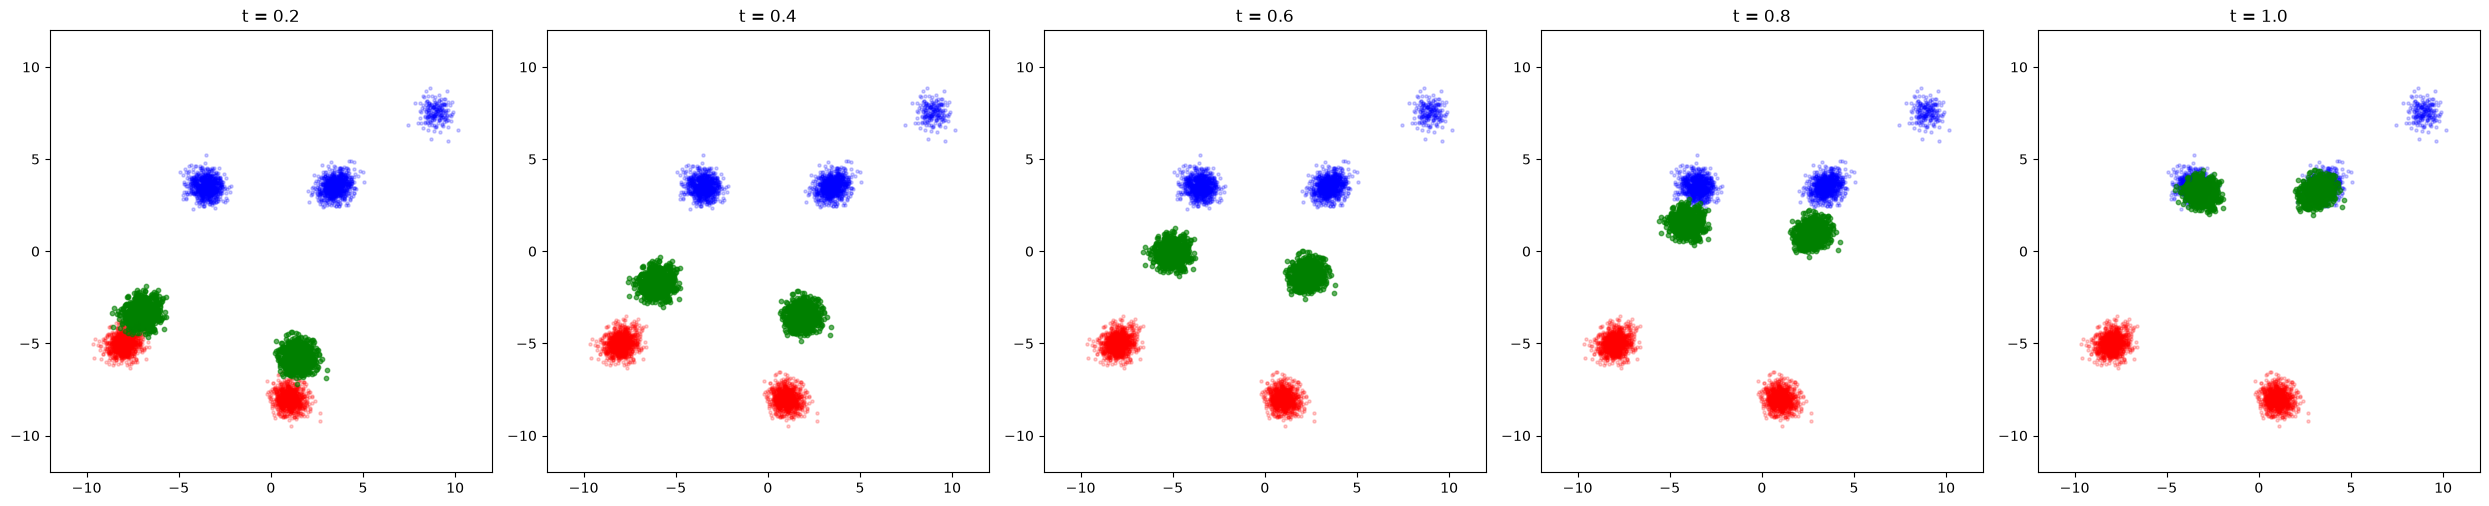

In [6]:
# パラメータ設定
ts = np.arange(0.2, 1.01, 0.2)
n_plots = len(ts)

# 横一列に並べるための設定
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

for i, t in enumerate(ts):
    # 線形補間
    Pt = (1 - t) * X + t * Z

    ax = axes[i]

    # 背景として X と Y を描画
    ax.scatter(X[:, 0], X[:, 1], s=5, c="red", alpha=0.2, label="X")
    ax.scatter(Y[:, 0], Y[:, 1], s=5, c="blue", alpha=0.2, label="Y")

    # 現在の補間点 Pt を描画
    ax.scatter(Pt[:, 0], Pt[:, 1], s=10, c="green", alpha=0.6, label="P_t")

    ax.set_title(f"t = {t:.1f}")
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)


plt.tight_layout()

plt.savefig(
    f"point_reg_{epsilon}_lambda_{Lambda}.eps", format="eps", bbox_inches="tight"
)
plt.show()